# Bacpipe Tutorial

This notebook walks through the main workflows of the `bacpipe` library — from inspecting configuration and loading audio, through generating embeddings with built-in and custom models, to running the full pipeline and benchmarking classifier performance.



Make sure to reset your config and settings files before running this notebook, 
as they may contain settings from previous runs that could prevent this notebook 
from finding the correct paths.
---

**Contents**
1. [Setup & Configuration](#1.-Setup-&-Configuration)
2. [Loading Audio Files](#2.-Loading-Audio-Files)
3. [Ground Truth Labels](#3.-Ground-Truth-Labels)
4. [End-to-End: bacpipe.play](#4.-End-to-End:-bacpipe.play)
5. [Full Pipeline - Single Model](#5.-Full-Pipeline---Single-Model)
6. [Full Pipeline - Multiple Models](#6.-Full-Pipeline---Multiple-Models)
7. [Generating Embeddings - Full Directory (Save to Disk)](#7.-Generating-Embeddings---Full-Directory-(Save-to-Disk))
8. [Generating Embeddings - Single File (In-Memory)](#8.-Generating-Embeddings---Single-File-(In-Memory))
9. [High-Level Workflow - generate_embeddings](#9.-High-Level-Workflow---generate_embeddings)
10. [Benchmarking Classifier Performance](#10.-Benchmarking-Classifier-Performance)

---
## 0. Imports & Working Directory

Set the working directory to the repo root and import the display utility.

In [4]:
# to run successfully the packages for jupyter notebook need to be installed:
# uv pip install ipykernel, ipython

from IPython.display import display
import os
from pathlib import Path

# load the specific package
import bacpipe

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import librosa as lb

%matplotlib inline

In [5]:
# get the path to the folder where the notebook is located
notebook_path = Path().resolve()

# get the name of the current notebook file
notebook_file = 'simple_use_cases'

# get the directoy where the notebook is located
notebook_dir = notebook_path.name

# working directory 
wd_path = notebook_path.parent

# set the audio directory to the folder 
# audio files directory
bacpipe.config.audio_dir = str( wd_path / 'bacpipe_data') 

# Change the value of the key main_results_dir in the namespace bacpipe.settings to change the directory 
# where the results of the tutorials are stored. By default, it is set to './bacpipe_results'.
bacpipe.settings.main_results_dir = str(wd_path / 'bacpipe_results')

# !WARNING! the following code deletes the folder where the results of this tutorial is stored to be sure to start with a clean folder. 
# If you have important data in this folder, please comment it before running this code.
folder_path = bacpipe.settings.main_results_dir
if os.path.exists(folder_path):
    # Prompt the user
    user_input = input(f"Are you sure you want to delete '{folder_path}'? (y/n): ").lower().strip()

    if user_input == 'y':
        import shutil
        shutil.rmtree(folder_path) 
        print(f"Folder {folder_path} deleted.")
    else:
        print("Operation cancelled.")

else:
    print(f"Folder {folder_path} not found.")

Operation cancelled.


---
## 1. Setup & Configuration

Import `bacpipe` and inspect the current configuration and settings. You can also list all available API endpoints, supported models, and the embedding dimensions for each model.

In [6]:
import bacpipe

print('Config:')
display(bacpipe.config)

print('Settings:')
display(bacpipe.settings)

Config:


namespace(audio_dir='/media/haupert/data/mes_projets/_cesco-ia/session_20260908/tp_bacpipe/bacpipe_data',
          overwrite=False,
          dashboard=True,
          models=['birdnet', 'perch_bird'],
          already_computed=False,
          dim_reduction_model='umap',
          evaluation_task=[])

Settings:


namespace(main_results_dir='/media/haupert/data/mes_projets/_cesco-ia/session_20260908/tp_bacpipe/bacpipe_results',
          embed_parent_dir='embeddings',
          dim_reduc_parent_dir='dim_reduced_embeddings',
          evaluations_dir='evaluations',
          model_base_path='bacpipe_model_checkpoints',
          device='cpu',
          global_batch_size=8,
          audio_suffixes=['.wav',
                          '.WAV',
                          '.aif',
                          '.mp3',
                          '.MP3',
                          '.flac',
                          '.ogg'],
          padding='wrap',
          avoid_pipelined_gpu_inference=False,
          nr_parallel_workers=False,
          rm_embedding_on_keyboard_interrupt=False,
          check_if_already_processed=True,
          check_if_already_dim_reduced=True,
          label_column='species',
          annotations_filename='annotations.csv',
          only_embed_annotations=False,
          min_annotat

---
## 4. End-to-End: `bacpipe.play`

`bacpipe.play` is the highest-level entry point. It runs the complete pipeline —
embeddings, classification, dimensionality reduction, evaluation, and an
interactive dashboard — in a single call. Ideal for a first exploration of a new
dataset across multiple models.

`play` does not return anything: all intermediate outputs are saved to disk and
the dashboard is launched automatically (unless disabled in the `config.yaml`
file). The models to run are passed with the `models` keyword (or taken from
`bacpipe.config.models`).

If a webpage with the dashboard is not automatically opened within your default
internet browser (e.g. chrome), copy then paste the URL displayed in the output
in a new page of your browser (e.g. http://localhost:5006).

The next cells select the device on which the models should run.
`bacpipe.settings.device` can be set to `'cpu'` (always works) or `'cuda'`
(only if a compatible NVIDIA GPU is available). If you do not have a GPU, leave
the default `'cpu'` to avoid CUDA errors.


In [4]:
# bacpipe.config.audio_dir = str( wd_path / 'bacpipe_data') # path to directory containing audio files
# bacpipe.settings.device = 'cpu' # choose 'cpu' or 'cuda' depending on your system configuration. 
# bacpipe.config.dim_reduction_model = 'pca'
# bacpipe.settings.classifier_threshold = 0.1 # set the threshold for the classifier. Default is 0.5.

# bacpipe.play(
#     models=['birdnet', 'birdnet_v3'],       # list of models to run. Supported models are in bacpipe.supported_models
# )

In [5]:
# bacpipe.visualize_using_dashboard(
#     models=['birdnet','birdnet_v3'],
#     audio_dir=bacpipe.config.audio_dir,
#     main_results_dir=bacpipe.settings.main_results_dir,
# )

---
## 7. Generating Embeddings - Full Directory (Save to Disk)

Instead of using the all-in-one pipeline functions, you can also call the `Loader`
and `Embedder` classes directly for more control. They are the core building
blocks of bacpipe, used internally by `run_pipeline_for_single_model` and
`run_pipeline_for_models`.

To process all audio files in a directory and persist the results, pass
`use_folder_structure=True` to the `Loader`. Bacpipe will create a timestamped
output directory, run inference using multithreading, and save embeddings,
metadata, and classifier predictions. Subsequent runs detect the saved files and
skip recomputation automatically.

The `loader_obj` returned by the `Loader` is the same object type returned by
`run_pipeline_for_single_model` and `run_pipeline_for_models`, so you can use it
in the same way to access embeddings, metadata, and predictions:

- `loader_obj.metadata_dict`: an overview of the audio data, where the embeddings
  were saved, per-file embedding counts, the sample rate, the segment length, and
  the total processed duration.
- `loader_obj.embeddings(return_type='array')`: all embeddings concatenated into a
  2D array where axis 0 is the time/segment axis and axis 1 the embedding
  dimension.
- `loader_obj.predictions(...)`: the pretrained classifier outputs, either as a
  per-file dictionary, a concatenated array, or a dataframe.


In [6]:
# MODEL_NAME = 'birdnet'

# # Create a loader object that will handle all the audio file, path and parameters needed to compute the embeddings for instance
# loader_obj = bacpipe.Loader(
#     audio_dir=bacpipe.config.audio_dir,
#     model_name=MODEL_NAME,
#     use_folder_structure=True
# )

# # Create an embededding object with the selected model (MODEL_NAME) passing the loader object in order to have the audio directory mapping
# embed_obj = bacpipe.Embedder(
#     model_name=MODEL_NAME, 
#     loader=loader_obj)

# # Process all files using multithreading
# embed_obj.run_inference_pipeline_using_multithreading()

# print('Metadata dict:')
# display(loader_obj.metadata_dict)

# print('Embeddings (array):')
# display(loader_obj.embeddings(return_type='array'))

# print('Predictions (array):')
# display(loader_obj.predictions(return_type='array'))

# print('Predictions (dataframe):')
# # display(loader_obj.predictions(return_type='dataframe'))

---
## 8. Generating Embeddings - Single File (In-Memory)

If you just want to generate embeddings for a single file without saving anything
to disk, instantiate the `Loader` and `Embedder` classes directly *without*
`use_folder_structure`. The embedding generation then runs in-memory and returns
Python objects without writing any files. This is useful for quick experimentation
or when you want to work with embeddings directly in memory.

Note that because nothing is saved to disk, `loader_obj.embeddings()` returns an
empty dict unless you keep a reference to the embedding arrays yourself (or save
them manually).


In [7]:
# Create a Loader without folder structure — nothing is written to disk
loader_obj = bacpipe.Loader(bacpipe.config.audio_dir)
embed_obj = bacpipe.Embedder('birdnet', loader_obj)

# convert loader_obj.files into a dataframe with columns 'file_path' and 'file_name' and 'label' 
# which is the parent folder name of the audio file)
df = pd.DataFrame({
    'file_path': [str(f) for f in loader_obj.files],
    'file_name': [f.name for f in loader_obj.files],
    'label': [f.parent.name for f in loader_obj.files]
})
# print the unique values of the label column with a list corresponding to the range of rows where the label is equal to the unique value
print('Unique values of the label column:')
for label in df['label'].unique():
    print(f'{label}: {list(df[df["label"] == label].index)}')

# Generate embeddings for the audio file N or sampled from the dataframe df
embeds = embed_obj.get_embeddings_from_model(df.sample(n=1).iloc[0]['file_path'])
embeds_ambient_sound = embed_obj.get_embeddings_from_model(loader_obj.files[0])
embeds_coal_tit = embed_obj.get_embeddings_from_model(loader_obj.files[2])

print('Since embeddings were not saved, .embeddings() returns empty:')
display(loader_obj.embeddings())

print('The embeddings are still accessible via the declared variable:')
display(embeds)

print('Classifier predictions are accessible through the embedder object:')
display(embed_obj.classifier.predictions)

print('Get the class label of the most highest values prediction:')
label_array = np.array(embed_obj.model.classes)
class_labels = label_array[np.argmax(embed_obj.classifier.predictions, axis=1)]
display(class_labels)

finding audio files: 158it [00:00, 46721.66it/s]
Found 150 number of audio files.
No model_name is passed, therefore no directory structure will be created.
2026-09-12 00:16:27.915533: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-12 00:16:27.988164: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Using device='cpu'
2026-09-12 00:16:31.918917: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device i

Unique values of the label column:
Ambient Sound: [0, 1]
Coal Tit: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
Eurasian Blackbird: [38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]
European Robin: [72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108]
Goldcrest: [109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146]
Great Green Bush-Cricket: [147]
Light Rain: [148, 149]


 processing batches: 100%|██████████| 1/1 [00:00<00:00,  1.89it/s]2026-09-12 00:16:34.949897: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
birdnet inference took 1.09s.                                     
 processing batches: 100%|██████████| 1/1 [00:00<00:00,  2.87it/s]2026-09-12 00:16:35.324196: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
birdnet inference took 0.37s.                                     
birdnet inference took 0.36s.                                     
No embedding files were found. Check that the path is right or if you actually have processed embeddings with None for file in /media/haupert/data/mes_projets/_cesco-ia/session_20260908/tp_bacpipe/bacpipe_data.


Since embeddings were not saved, .embeddings() returns empty:


None

...

array([[0.        , 1.9451475 , 0.64854884, ..., 0.57011646, 1.9761311 ,
        0.77350634]], dtype=float32)

Classifier predictions are accessible through the embedder object:


tensor([[1.7785e-10, 4.3914e-12, 7.4775e-10,  ..., 3.2758e-09, 2.1129e-07,
         1.4082e-09],
        [8.1288e-07, 9.0841e-09, 1.0547e-09,  ..., 4.9034e-10, 1.0367e-07,
         1.8711e-09],
        [5.2137e-11, 4.1143e-12, 8.8988e-10,  ..., 6.3272e-10, 2.8469e-08,
         8.9829e-11]])

Get the class label of the most highest values prediction:


array(['Coal Tit', 'Little Owl', 'Coal Tit'], dtype='<U34')

### 9.1 Load and concatenate audio files yourself, then pass the result to bacpipe

You can also load and preprocess audio yourself and pass it directly to an
`Embedder` — useful when you need custom loading logic or want to process audio
that isn't stored on disk.

Here we load all test audio files with `librosa`, concatenate the samples into a
single long 1D numpy array, and pass it to `Embedder.generate_embeddings_from_audio_array`.
The method windows the audio into segments of the model's input length and returns
the embedding of each window. `bacpipe.ensure_models_exist` guarantees that the
model checkpoint is present locally, downloading it from the Hugging Face Hub on
first use.


In [7]:
# load and concatenate audio, then pass it directly to an Embedder

list_audio_files = bacpipe.get_audio_files(
    bacpipe.config.audio_dir,
    return_type='str'
)

# convert loader_obj.files into a dataframe with columns 'file_path' and 'file_name' and 'label' 
# which is the parent folder name of the audio file)
df = pd.DataFrame({
    'file_path': [f for f in list_audio_files],
    'file_name': [(Path(f).name) for f in list_audio_files],
    'label': [Path(f).parent.name for f in list_audio_files]
})
# print the unique values of the label column with a list corresponding to the range of rows where the label is equal to the unique value
print('Unique values of the label column:')
for label in df['label'].unique():
    print(f'{label}: {list(df[df["label"] == label].index)}')

# load the background sound
filename = df['file_path'][df['label'] == 'Light Rain'].iloc[1]
background_sound, _ = lb.load(filename, sr=48000, duration=3)

audio_concatenate = []
audio_chunks = []
audio_concatenate_mixed = []
audio_chunks_mixed = []
for file in list_audio_files:
    aud, sr = lb.load(file, sr=48000, duration=3)
    # zero pad the audio to 3 seconds
    if len(aud) < 3 * sr:
        print(f'Zero padding {file} from {len(aud)} to {3 * sr} samples.')
        aud = np.pad(aud, 3 * sr - len(aud), 'constant')
    audio_chunks.append(aud)
    audio_concatenate.extend(aud)
    # add background
    audio_mixed = aud * 0.1 + background_sound *.90
    audio_chunks_mixed.append(audio_mixed)
    audio_concatenate_mixed.extend(audio_mixed)

df['audio'] = audio_chunks
df['audio_mixed'] = audio_chunks_mixed


finding audio files: 158it [00:00, 184236.87it/s]
Found 150 number of audio files.


Unique values of the label column:
Ambient Sound: [0, 1]
Coal Tit: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
Eurasian Blackbird: [38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]
European Robin: [72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108]
Goldcrest: [109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146]
Great Green Bush-Cricket: [147]
Light Rain: [148, 149]


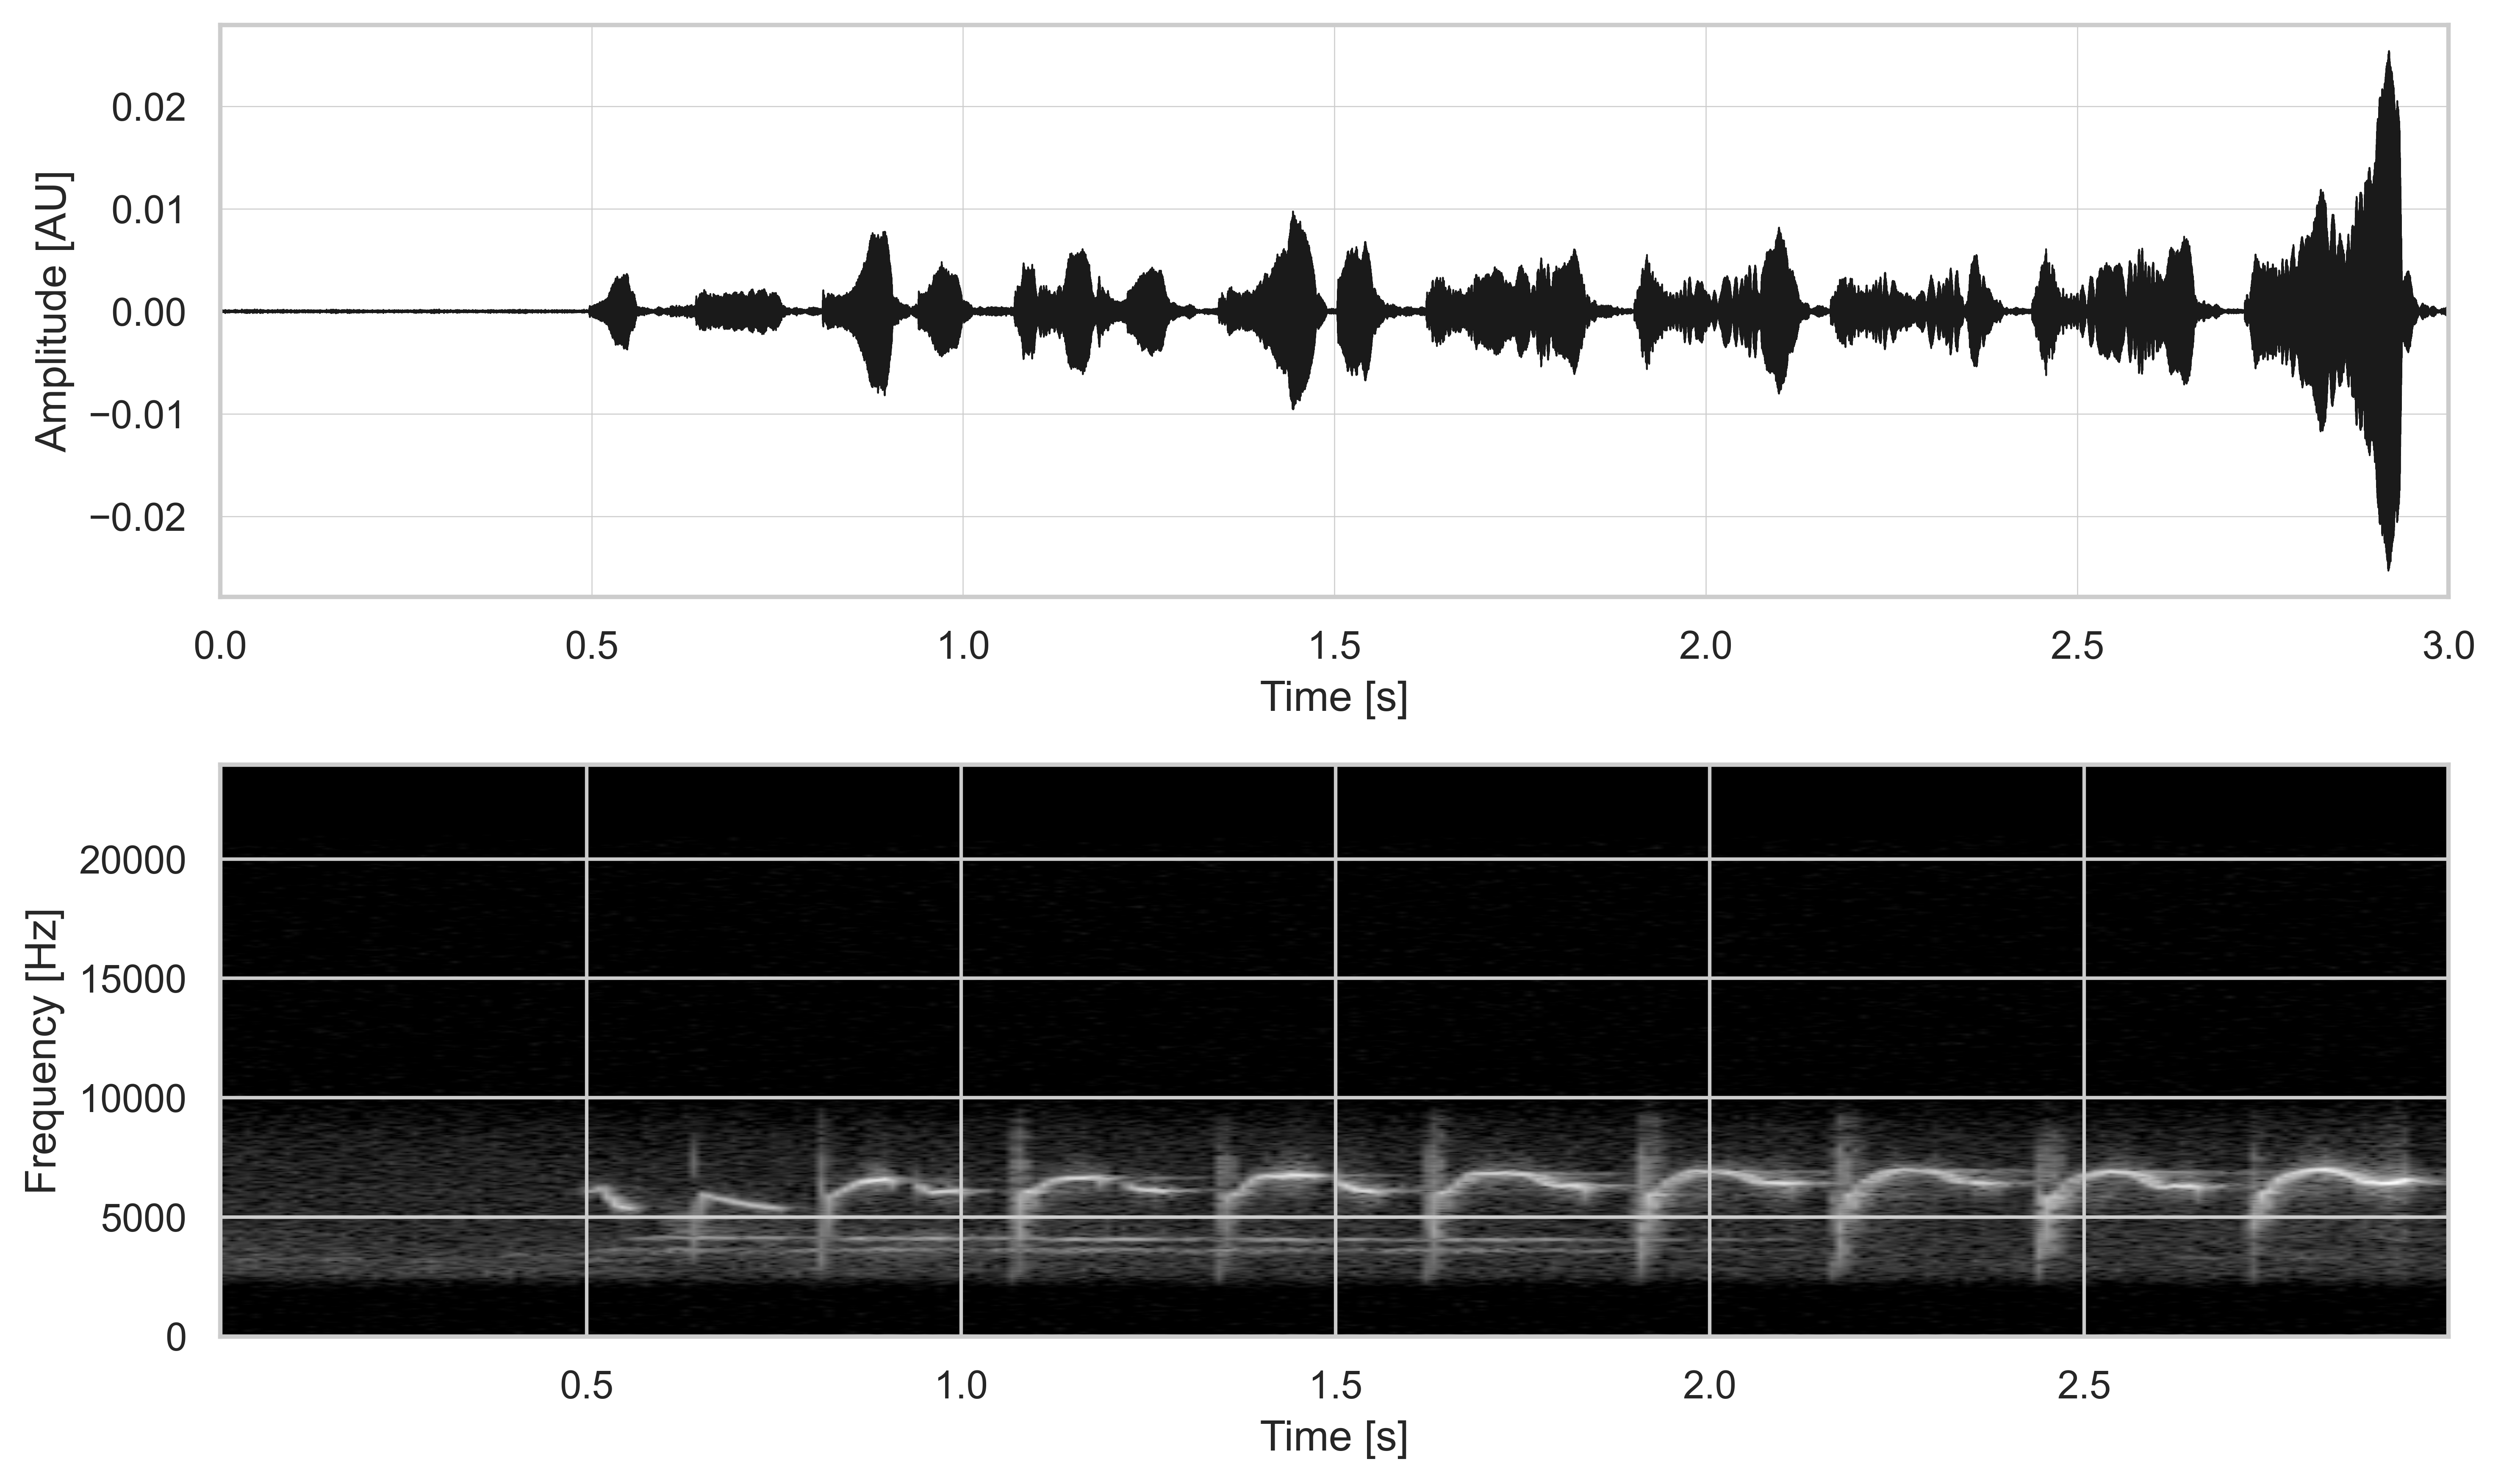

In [8]:
# display the spectrogram of the audio
from maad import sound, util

fs = 48000
label = 'Goldcrest'
index = df[df['label'] == label].sample().index
s = df['audio'][index].iloc[0]

# display the spectrogram of the first 3 seconds of audio
Sxx, tn, fn, ext = sound.spectrogram(s, fs=fs) 
fig, ax = plt.subplots(2,1, figsize=(10,6))
util.plot_wave(s, fs, ax=ax[0])
util.plot_spectrogram(Sxx, ext, db_range=96, gain=30, colorbar=False, ax=ax[1])

# play the sound
from IPython.display import Audio
Audio(s, rate=fs)

/home/haupert/miniconda3/envs/bacpipe/lib/python3.11/site-packages/maad/util/miscellaneous.py:413: RuntimeWarning: divide by zero encountered in log10
  y = 10*log10(x)   # take log


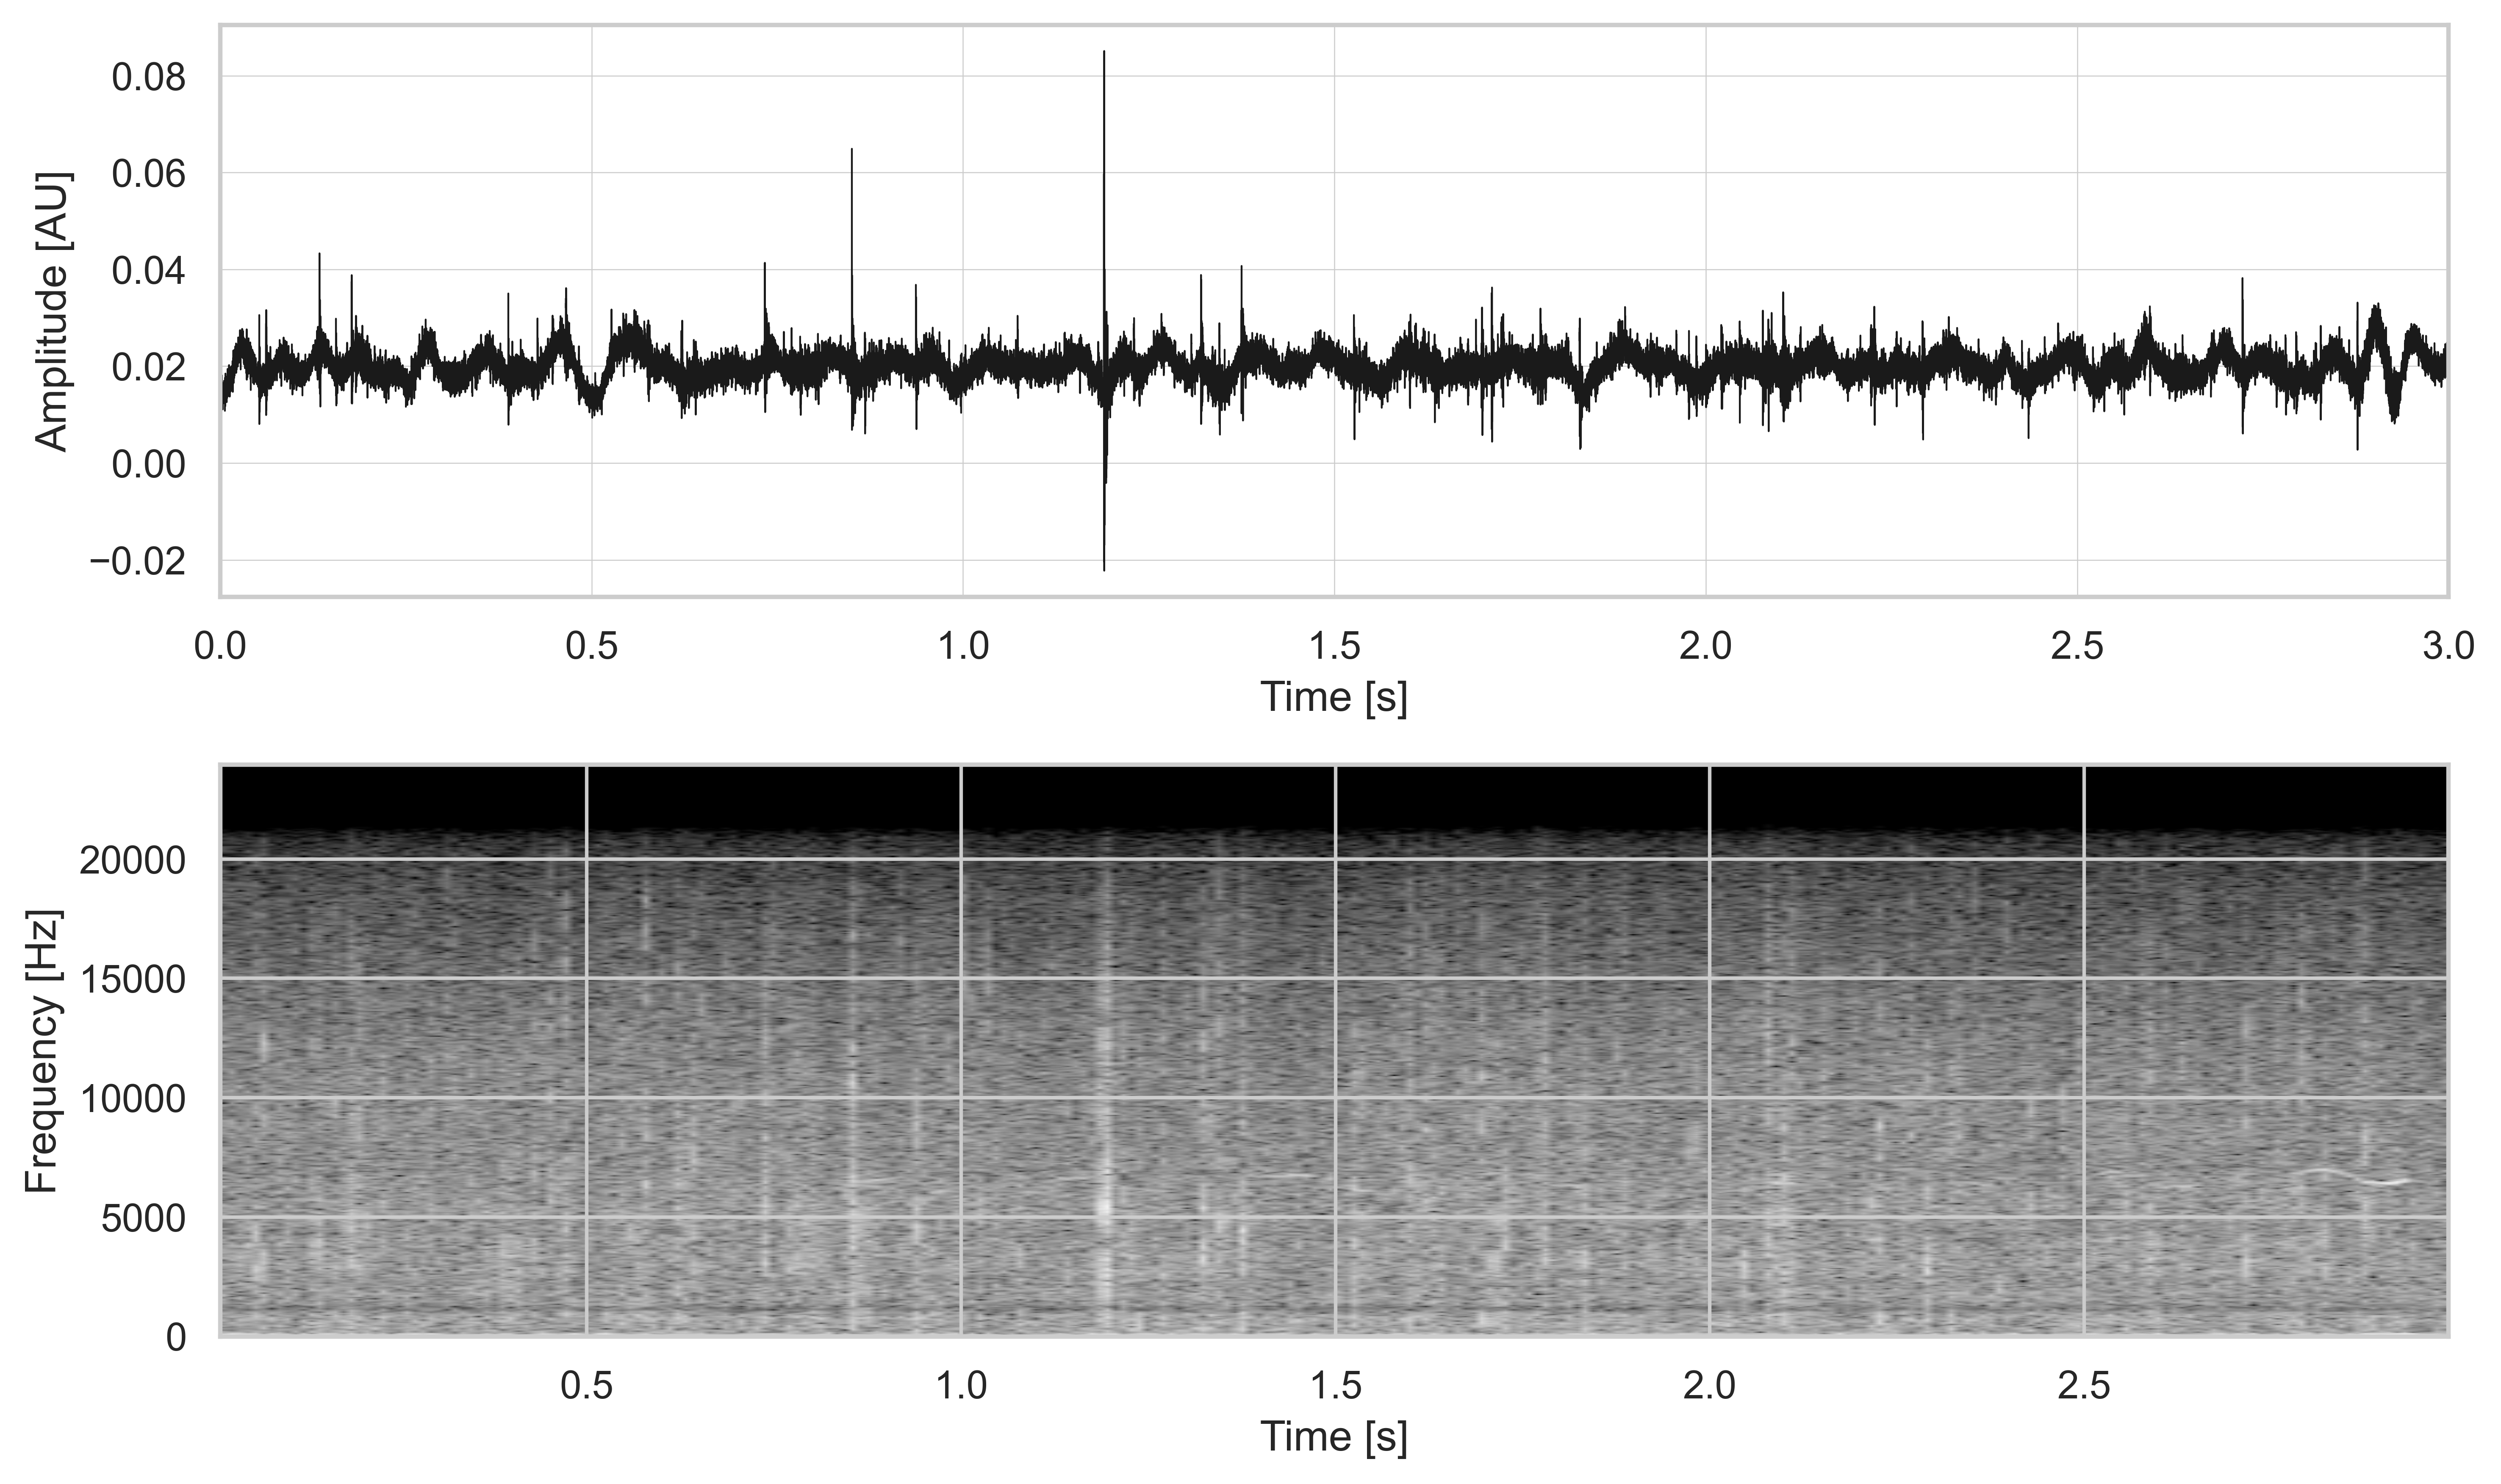

In [9]:
s = df['audio_mixed'][index].iloc[0]  # get the first audio chunk

# display the spectrogram of the first 3 seconds of audio
Sxx, tn, fn, ext = sound.spectrogram(s, fs=fs) 
fig, ax = plt.subplots(2,1, figsize=(10,6))
util.plot_wave(s, fs, ax=ax[0])
util.plot_spectrogram(Sxx, ext, db_range=96, gain=30, colorbar=False, ax=ax[1])

# play the sound
from IPython.display import Audio
Audio(s, rate=fs)

In [10]:
# check if the model exists, if not, download it
bacpipe.ensure_models_exist(bacpipe.settings.model_base_path, ['birdnet'])

# embed
embed_obj = bacpipe.Embedder('birdnet')
embeds = embed_obj.generate_embeddings_from_audio_array(np.array(audio_concatenate))
embeds_mixed = embed_obj.generate_embeddings_from_audio_array(np.array(audio_concatenate_mixed))
embed_background = embed_obj.generate_embeddings_from_audio_array(background_sound)
# subtract the background sound embeddings from the mixed audio embeddings
embeds_corrected = np.array(embeds_mixed) - np.array(embed_background)


# # check the classification predictions for the audio array
# print('Classification predictions for the audio array:')
# display(embed_obj.classifier.predictions)

# # Get the class labels of the most highest values prediction for the audio array
# print('Get the class labels of the most highest values prediction for the audio array:')
# label_array = np.array(embed_obj.model.classes)
# for i in range(embed_obj.classifier.predictions.shape[0]):
#     class_label = label_array[np.argmax(embed_obj.classifier.predictions[i])]
#     print(f'Prediction {i}: {class_label}')

Checking if the selected models require a checkpoint, and if so, if the checkpoint already exists.

birdnet checkpoint exists.

2026-09-14 08:58:43.893380: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-14 08:58:43.920630: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Using device='cpu'
2026-09-14 08:58:46.842584: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-09-14 08:58:4

In [12]:
from sklearn.neighbors import KNeighborsClassifier

# X is the embeddings and y is the labels
X = embeds
y = df["label"].to_numpy()

custom_classifier = KNeighborsClassifier(
    n_neighbors=1, 
    metric="cosine")

custom_classifier.fit(X, y)

# # use the custom classifier to predict the label of the first embedding
# prediction = custom_classifier.predict(embeds[100].reshape(1, -1))
# prediction

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'cosine'
,metric_params,None
,n_jobs,None


In [13]:
# compute the accuracy of the custom classifier on the embeddings of the mixed audio
y_pred = custom_classifier.predict(embeds_mixed)
y_true = df["label"].to_numpy()

# compute the accuracy
accuracy = np.mean(y_pred == y_true)
print(f'Accuracy on mixed audio: {accuracy:.2f}')

# compute the accuracy of the custom classifier on the embeddings of the mixed audio
y_pred = custom_classifier.predict(embeds_corrected)
y_true = df["label"].to_numpy()

# compute the accuracy
accuracy = np.mean(y_pred == y_true)
print(f'Accuracy on corrected audio: {accuracy:.2f}')

Accuracy on mixed audio: 0.46
Accuracy on corrected audio: 0.97


---
## 10. Benchmarking Classifier Performance

`bacpipe.benchmark` evaluates a model's pretrained classifier against your ground
truth annotations. It aligns predictions and ground truth to the same timestamps,
resolves label mismatches (for example hyphen or spacing differences such as
*Red-Shouldered Hawk* vs *Red Shouldered Hawk*) with a fuzzy-matching fallback,
and returns a per-species `sklearn` classification report with precision, recall,
and F1.

If predictions have already been generated for this dataset, the function loads
them from disk and runs very quickly.


In [ ]:
results = bacpipe.benchmark(
    'birdnet',
    'bacpipe/tests/test_data',
    annotations_file='annotations.csv'
)
display(results)

Fetching ground truth and mapping it to model timestamps.

INFO:bacpipe:Fetching ground truth and mapping it to model timestamps.


Multiple embeddings found for model birdnet in bacpipe_results/simple_use_cases/test_data/embeddings. Using the most recent path.

INFO:bacpipe:
Multiple embeddings found for model birdnet in bacpipe_results/simple_use_cases/test_data/embeddings. Using the most recent path.

                                                                                                  
The simultaneous labels column of the ground truth has values exceeding 1. This means you have multi-label ground truth annotations. If this should not be happening ensure the ground truth is created correcly.

The simultaneous labels column of the ground truth has values exceeding 1. This means you have multi-label ground truth annotations. If this should not be happening ensure the ground truth is created correcly.

                                                                       

{'report': {'Common Cuckoo': {'precision': 1.0,
   'recall': 0.8181818181818182,
   'f1-score': 0.9,
   'support': 11.0},
  'Eurasian Blackbird': {'precision': 1.0,
   'recall': 0.6428571428571429,
   'f1-score': 0.782608695652174,
   'support': 28.0},
  'micro avg': {'precision': 1.0,
   'recall': 0.6923076923076923,
   'f1-score': 0.8181818181818182,
   'support': 39.0},
  'macro avg': {'precision': 1.0,
   'recall': 0.7305194805194806,
   'f1-score': 0.841304347826087,
   'support': 39.0},
  'weighted avg': {'precision': 1.0,
   'recall': 0.6923076923076923,
   'f1-score': 0.8157190635451506,
   'support': 39.0},
  'samples avg': {'precision': 0.6923076923076923,
   'recall': 0.6923076923076923,
   'f1-score': 0.6923076923076923,
   'support': 39.0}},
 'gt_binary': array([[1, 0],
        [1, 0],
        [1, 0],
        [1, 0],
        [1, 0],
        [1, 0],
        [1, 0],
        [1, 0],
        [1, 0],
        [1, 0],
        [1, 0],
        [0, 1],
        [0, 1],
        [0, 1]